In [18]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent ))

In [19]:
from src.dominick import DominickDataLoader
from src.eda import EDA
from matplotlib import pyplot as plt
import numpy as np

loader = DominickDataLoader()
df = loader.load("elasticity_dataset.csv")
eda = EDA()

In [20]:
upc = 3410010505
store = 130

In [21]:
print("=" * 80)
print(f"ESTUDIO COMPLETO PARA UPC {upc} | TIENDA {store}")
print("=" * 80)

# 1. Filtrado por UPC
df_upc = df[(df["upc_code"] == upc) & (df["store_code"] == store)].copy()
print(f"Nº observaciones para UPC {upc} | TIENDA {store}: {len(df_upc)}")

if df_upc.empty:
    print("No hay datos para este UPC.")

ESTUDIO COMPLETO PARA UPC 3410010505 | TIENDA 130
Nº observaciones para UPC 3410010505 | TIENDA 130: 141


In [22]:
# -------------------------------------------------------------------------
# 2. Análisis de NaNs
# -------------------------------------------------------------------------
print("\n=== NaNs ===")
nan_df = eda.analyze_nans(df_upc)
display(nan_df)


=== NaNs ===


,n_nans,pct_nans
store_code,0,0.0
upc_code,0,0.0
category_code,0,0.0
week_id,0,0.0
log_liters_sold,0,0.0
log_price_per_liter,0,0.0
on_promo,0,0.0
week_rank,0,0.0
sin_52,0,0.0
cos_52,0,0.0


In [23]:
# -------------------------------------------------------------------------
# 4. Correlación global + regresión
# -------------------------------------------------------------------------
print("\n=== Global Correlation Analysis (UPC) ===")
x_col = "log_price_per_liter"
y_col = "log_liters_sold"

from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

# 1) Preparamos datos (quitamos NaNs)
data = df_upc[[x_col, y_col]].dropna()
x = data[x_col]
y = data[y_col]

print(f"N observaciones usadas: {len(data)}")

# 2) Correlaciones
pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

print(f"\nCorrelación de Pearson: r = {pearson_r:.4f}, p = {pearson_p:.4e}")
print(f"Correlación de Spearman: ρ = {spearman_r:.4f}, p = {spearman_p:.4e}")

# 3) Regresión lineal OLS: y ~ x
X = sm.add_constant(x)        # añade intercepto
model = sm.OLS(y, X).fit()

print("\n=== Regresión OLS: log_liters_sold ~ log_price_per_liter ===")
print(f"Intercepto: {model.params['const']:.4f}")
print(f"Coef (elasticidad OLS simple): {model.params[x_col]:.4f}")
print(f"R²: {model.rsquared:.4f}")
print(f"p-valor coeficiente: {model.pvalues[x_col]:.4e}")
print(f"stderr coeficiente: {model.bse[x_col]:.4f}")


=== Global Correlation Analysis (UPC) ===
N observaciones usadas: 141

Correlación de Pearson: r = 0.1202, p = 1.5584e-01
Correlación de Spearman: ρ = 0.0565, p = 5.0605e-01

=== Regresión OLS: log_liters_sold ~ log_price_per_liter ===
Intercepto: 1.5377
Coef (elasticidad OLS simple): 1.5451
R²: 0.0144
p-valor coeficiente: 1.5584e-01
stderr coeficiente: 1.0828


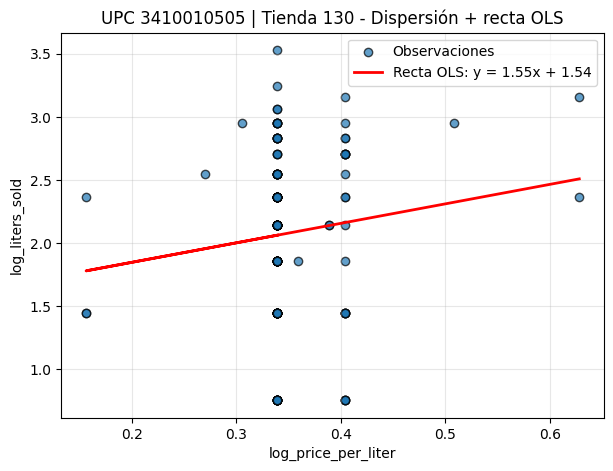

In [24]:
x = df_upc["log_price_per_liter"].values
y = df_upc["log_liters_sold"].values
m, b = np.polyfit(x, y, 1)  # pendiente y ordenada

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.7, edgecolor="k", label="Observaciones")
plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2,
    label=f"Recta OLS: y = {m:.2f}x + {b:.2f}",
)
plt.xlabel("log_price_per_liter")
plt.ylabel("log_liters_sold")
plt.title(f"UPC {upc} | Tienda {store} - Dispersión + recta OLS")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

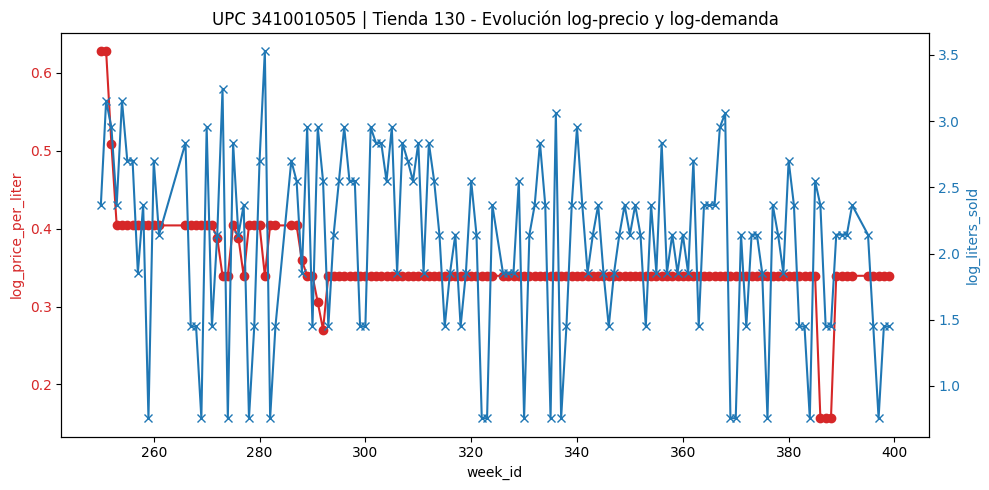

In [25]:
# -------------------------------------------------------------------------
# 6. Evolución temporal de precio y ventas (escala log)
# -------------------------------------------------------------------------
df_plot = df_upc.sort_values("week_id").copy()

fig, ax1 = plt.subplots(figsize=(10, 5))

color_price = "tab:red"
color_demand = "tab:blue"

# Precio
ax1.set_xlabel("week_id")
ax1.set_ylabel("log_price_per_liter", color=color_price)
ax1.plot(df_plot["week_id"], df_plot["log_price_per_liter"],
         color=color_price, marker="o", label="log_price_per_liter")
ax1.tick_params(axis="y", labelcolor=color_price)

# Segundo eje para demanda
ax2 = ax1.twinx()
ax2.set_ylabel("log_liters_sold", color=color_demand)
ax2.plot(df_plot["week_id"], df_plot["log_liters_sold"],
         color=color_demand, marker="x", label="log_liters_sold")
ax2.tick_params(axis="y", labelcolor=color_demand)

plt.title(f"UPC {upc} | Tienda {store} - Evolución log-precio y log-demanda")
fig.tight_layout()
plt.show()